# Backtest Results
Visualizes simulated trading performance from `logs/backtest_trades.csv`.
Run `python -m backtest.engine` first to generate the data.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Make project root importable
ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backtest.metrics import compute_metrics

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

TRADES_PATH = ROOT / "logs" / "backtest_trades.csv"
STARTING_BALANCE = 1000.0

In [2]:
df = pd.read_csv(TRADES_PATH, parse_dates=["timestamp"])
df["won"] = df["won"].astype(str).str.lower() == "true"
df["category"] = df["contract_id"].str.extract(r"KX([A-Z]+)-")[0].map(
    lambda s: "crypto" if s in ("BTC", "ETH") else ("weather" if s in ("NY", "LAX", "CHI", "NYTEMP", "NYTEMPHI", "CHIRAIN", "NYRAIN", "LAXRAIN") else "sports")
)
print(f"Loaded {len(df)} trades")
df.head()

Loaded 10 trades


,contract_id,timestamp,p_model,market_price,side,n_contracts,cost,edge,resolved_yes,won,pnl,balance,cumulative_pnl,category
0,KXBTC-26APR28-T9000000,2026-04-28 18:00:00+00:00,0.72,0.606057,YES,82,49.6967,0.1139,0,False,-49.6967,950.30,-49.6967,crypto
1,KXBTC-26APR28-T8500000,2026-04-28 18:00:00+00:00,0.88,0.805511,YES,58,46.7196,0.0745,1,True,11.2804,961.58,-38.4163,crypto
2,KXBTC-26APR28-T8000000,2026-04-28 18:00:00+00:00,0.95,0.832330,YES,57,47.4428,0.1177,1,True,9.5572,971.14,-28.8591,crypto
3,KXETH-26APR28-T280000,2026-04-28 18:00:00+00:00,0.63,0.558136,YES,70,39.0695,0.0719,1,True,30.9305,1002.07,2.0713,crypto
4,KXNYRAIN-26APR28,2026-04-28 18:00:00+00:00,0.33,0.451602,NO,91,49.9042,0.1216,1,False,-49.9042,952.17,-47.8329,weather


## Performance Summary

In [3]:
m = compute_metrics(df, STARTING_BALANCE)

go = m["sharpe_ratio"] > 1.0 and m["win_rate"] > 0.52 and m["max_drawdown_pct"] > -30
decision = "✅ GO for live trading" if go else "❌ Stay in dry-run"

rows = [
    ("Trades",         m["n_trades"],                        ""),
    ("Total P&L",      f"${m['total_pnl']:+.2f}",            ""),
    ("ROI",            f"{m['roi_pct']:+.2f}%",              ""),
    ("Win Rate",       f"{m['win_rate']:.1%}",               "✅" if m["win_rate"] > 0.52 else "⚠️"),
    ("Avg Edge",       f"{m['avg_edge']:.4f}",               ""),
    ("Sharpe Ratio",   f"{m['sharpe_ratio']:.3f}",           "✅" if m["sharpe_ratio"] > 1.0 else "⚠️"),
    ("Sortino Ratio",  f"{m['sortino_ratio']:.3f}",          ""),
    ("Max Drawdown",   f"${m['max_drawdown']:.2f} ({m['max_drawdown_pct']:.1f}%)", ""),
    ("Week 6 Gate",    decision,                             ""),
]
summary = pd.DataFrame(rows, columns=["Metric", "Value", "Gate"])
summary

,Metric,Value,Gate
0,Trades,10,
1,Total P&L,$+70.97,
2,ROI,+7.10%,
3,Win Rate,40.0%,⚠️
4,Avg Edge,0.0890,
5,Sharpe Ratio,1.459,✅
6,Sortino Ratio,7.271,
7,Max Drawdown,$-107.30 (-10.7%),
8,Week 6 Gate,❌ Stay in dry-run,


## Cumulative P&L

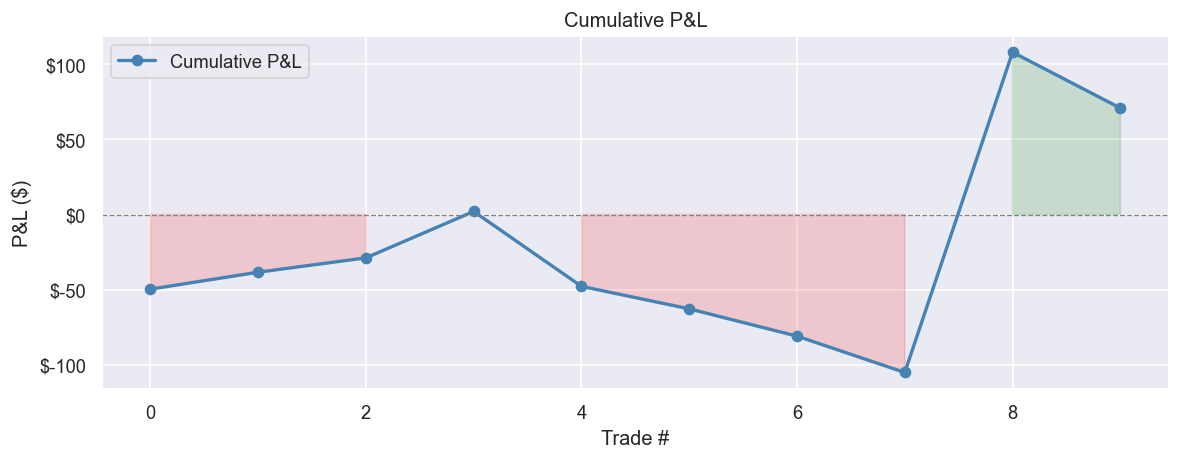

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df.index, df["cumulative_pnl"], marker="o", linewidth=2, color="steelblue", label="Cumulative P&L")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.fill_between(df.index, df["cumulative_pnl"], 0,
                where=df["cumulative_pnl"] >= 0, alpha=0.15, color="green")
ax.fill_between(df.index, df["cumulative_pnl"], 0,
                where=df["cumulative_pnl"] < 0, alpha=0.15, color="red")

ax.set_xlabel("Trade #")
ax.set_ylabel("P&L ($)")
ax.set_title("Cumulative P&L")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.legend()
plt.tight_layout()
plt.show()

## Account Balance Over Time

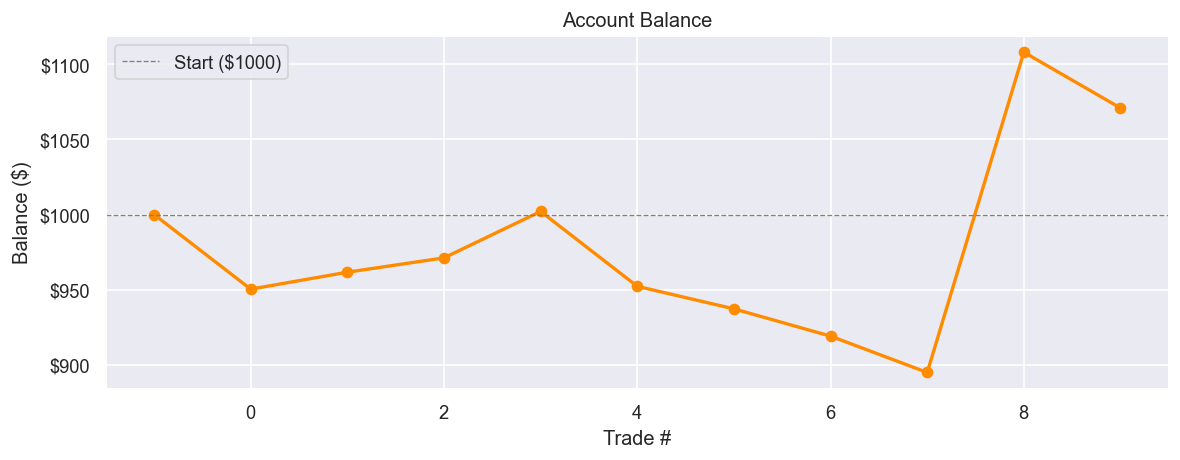

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

balance_series = pd.concat([
    pd.Series([STARTING_BALANCE], index=[-1]),
    df["balance"],
])
ax.plot(balance_series.index, balance_series.values, marker="o", linewidth=2, color="darkorange")
ax.axhline(STARTING_BALANCE, color="gray", linewidth=0.8, linestyle="--", label=f"Start (${STARTING_BALANCE:.0f})")

ax.set_xlabel("Trade #")
ax.set_ylabel("Balance ($)")
ax.set_title("Account Balance")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.legend()
plt.tight_layout()
plt.show()

## Per-Trade P&L

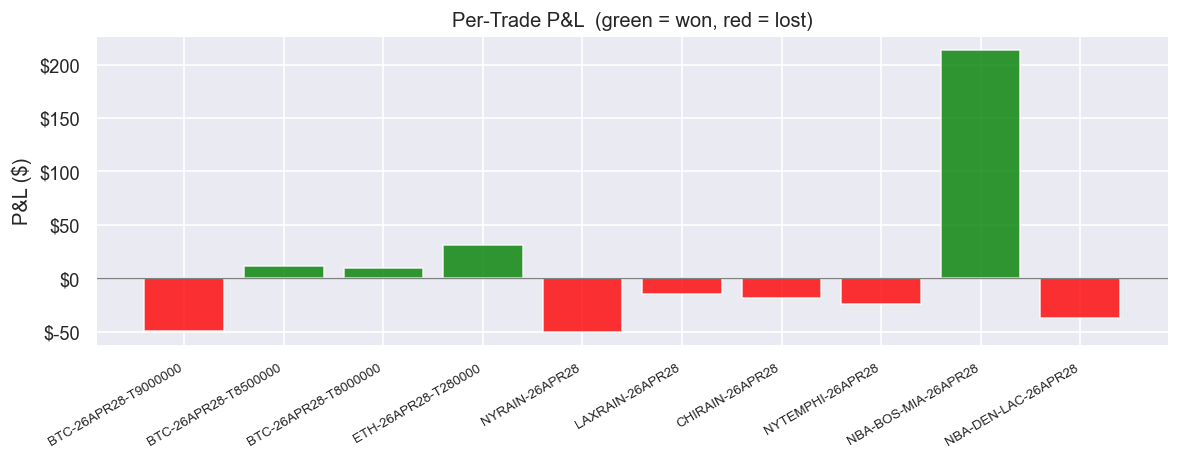

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ["green" if w else "red" for w in df["won"]]
bars = ax.bar(df.index, df["pnl"], color=colors, alpha=0.8, edgecolor="white")
ax.axhline(0, color="gray", linewidth=0.8)

labels = [c.replace("KX", "") for c in df["contract_id"]]
ax.set_xticks(df.index)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("P&L ($)")
ax.set_title("Per-Trade P&L  (green = won, red = lost)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
plt.tight_layout()
plt.show()

## Win Rate by Category

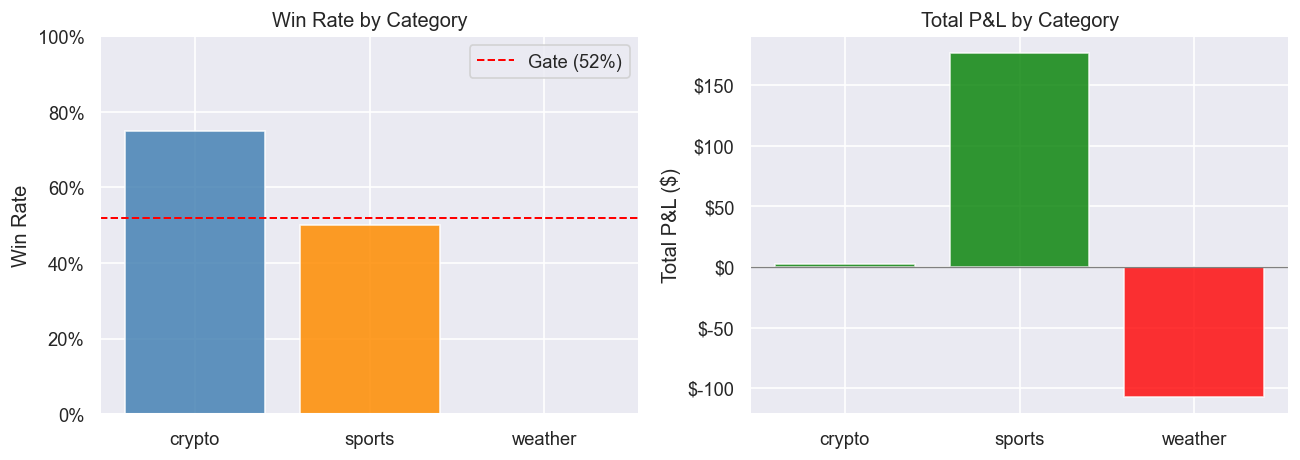

,category,n_trades,win_rate,total_pnl
0,crypto,4,0.75,2.0714
1,sports,2,0.50,176.1954
2,weather,4,0.00,-107.3007


In [7]:
cat_stats = df.groupby("category").agg(
    n_trades=("won", "count"),
    win_rate=("won", "mean"),
    total_pnl=("pnl", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Win rate
ax = axes[0]
bars = ax.bar(cat_stats["category"], cat_stats["win_rate"], color=["steelblue", "darkorange", "mediumseagreen"][:len(cat_stats)], alpha=0.85)
ax.axhline(0.52, color="red", linewidth=1.2, linestyle="--", label="Gate (52%)")
ax.set_ylim(0, 1)
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Category")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()

# Total P&L
ax = axes[1]
pnl_colors = ["green" if v >= 0 else "red" for v in cat_stats["total_pnl"]]
ax.bar(cat_stats["category"], cat_stats["total_pnl"], color=pnl_colors, alpha=0.8)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("Total P&L ($)")
ax.set_title("Total P&L by Category")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))

plt.tight_layout()
plt.show()
cat_stats

## Edge vs. P&L

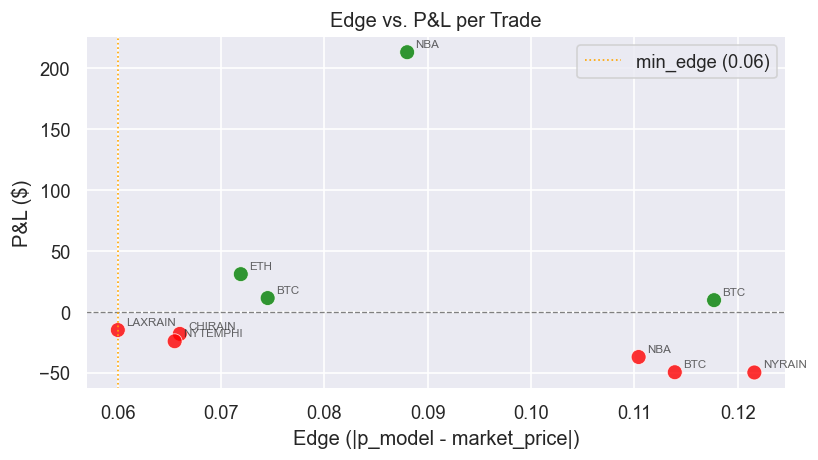

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["green" if w else "red" for w in df["won"]]
scatter = ax.scatter(df["edge"], df["pnl"], c=colors, alpha=0.8, s=80, edgecolors="white", linewidth=0.5)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0.06, color="orange", linewidth=1, linestyle=":", label="min_edge (0.06)")

for _, row in df.iterrows():
    ax.annotate(
        row["contract_id"].replace("KX", "").split("-")[0],
        (row["edge"], row["pnl"]),
        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7,
    )

ax.set_xlabel("Edge (|p_model - market_price|)")
ax.set_ylabel("P&L ($)")
ax.set_title("Edge vs. P&L per Trade")
ax.legend()
plt.tight_layout()
plt.show()

## Model Calibration: p_model vs. Outcomes

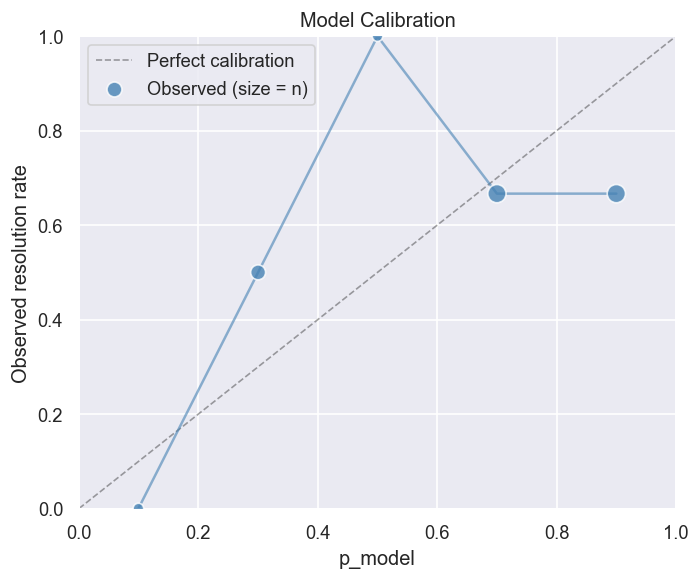

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

# Perfect calibration line
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Perfect calibration")

# Bucket p_model into bins and compute observed resolution rate
df["p_bin"] = pd.cut(df["p_model"], bins=np.arange(0, 1.1, 0.2), include_lowest=True)
cal = df.groupby("p_bin", observed=True)["resolved_yes"].agg(["mean", "count"]).reset_index()
bin_centers = [iv.mid for iv in cal["p_bin"]]

sc = ax.scatter(bin_centers, cal["mean"], s=cal["count"] * 40,
                color="steelblue", alpha=0.8, edgecolors="white", zorder=3, label="Observed (size = n)")
ax.plot(bin_centers, cal["mean"], color="steelblue", linewidth=1.5, alpha=0.6)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("p_model")
ax.set_ylabel("Observed resolution rate")
ax.set_title("Model Calibration")
ax.legend()
plt.tight_layout()
plt.show()